# Project: ARIMA + GARCH + HMM Modeling on Synthetic Data

### Objective
This project demonstrates how three classic time-series models — **ARIMA**, **GARCH**, and **Hidden Markov Models (HMMs)** — can be combined to analyze synthetic return data. The goal is to separate mean dynamics, volatility clustering, and regime switching in a controlled environment.

### Steps
1. **Data Generation**  
   - A synthetic AR(1)-GARCH(1,1) process is simulated to mimic stylized facts of financial returns: short-term autocorrelation, volatility clustering, and heteroskedasticity.
   - Returns are accumulated into a "price" series for visualization.

2. **Mean Dynamics (ARIMA)**  
   - An ARIMA(1,0,1) model is fitted to returns.
   - This captures short-term autocorrelation and tests whether returns exhibit predictable components.

3. **Volatility Dynamics (GARCH)**  
   - A GARCH(1,1) model is fitted to the same returns.
   - This models conditional variance and identifies periods of higher or lower volatility.

4. **Regime Classification (HMM)**  
   - A 2-state Gaussian Hidden Markov Model is applied to the log of squared returns.
   - The HMM separates the series into **LowVol** and **HighVol** regimes, reflecting calm and turbulent periods.

### Outputs
- **ARIMA summary**: coefficients for autoregression and moving average terms.  
- **GARCH summary**: parameters describing volatility shocks and persistence.  
- **HMM states**: probabilities and transitions between low and high volatility regimes.  
- **Plots**: synthetic price path, ARIMA residuals, conditional volatility, regime timeline, and rolling variance.

### Model Usage
- **ARIMA** explains the predictable part of returns.  
- **GARCH** captures volatility clustering and time-varying risk.  
- **HMM** detects hidden regimes that standard models may miss.  
Together, they form a complete framework for understanding return dynamics in financial or economic time series.


In [3]:
print("Hello, World!")

Hello, World!



================ ARIMA Summary ================
                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 2500
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -4299.792
Date:                Wed, 01 Oct 2025   AIC                           8607.584
Time:                        12:22:02   BIC                           8630.880
Sample:                    01-01-2010   HQIC                          8616.042
                         - 08-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0154      0.045     -0.344      0.731      -0.103       0.073
ar.L1          0.3867      0.043      9.015      0.000       0.303       0.471
ma.

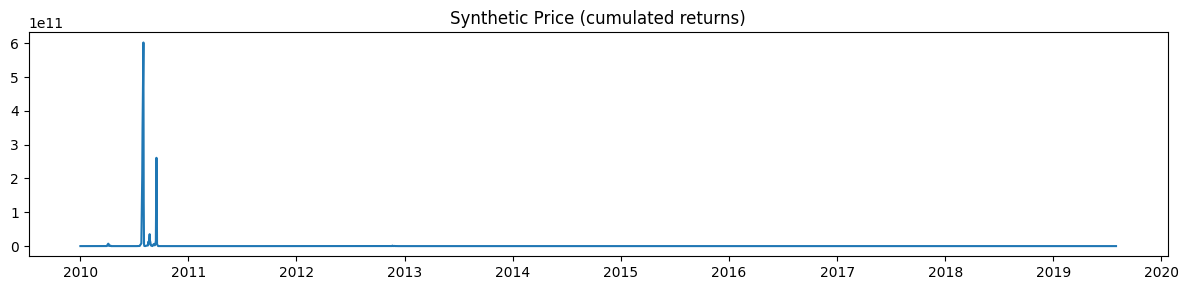

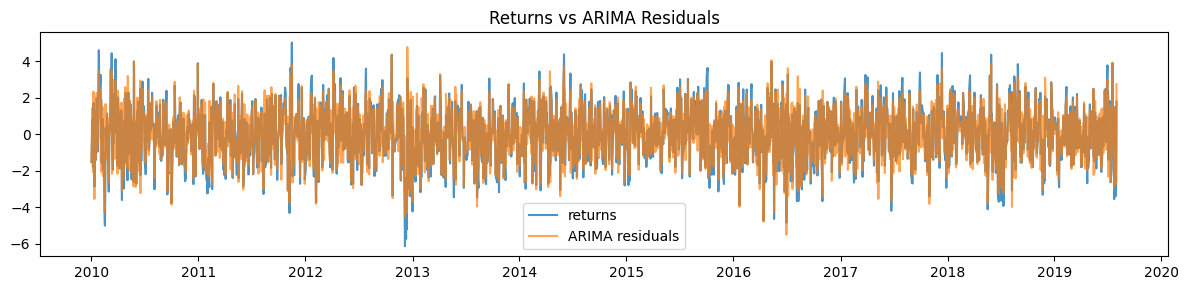

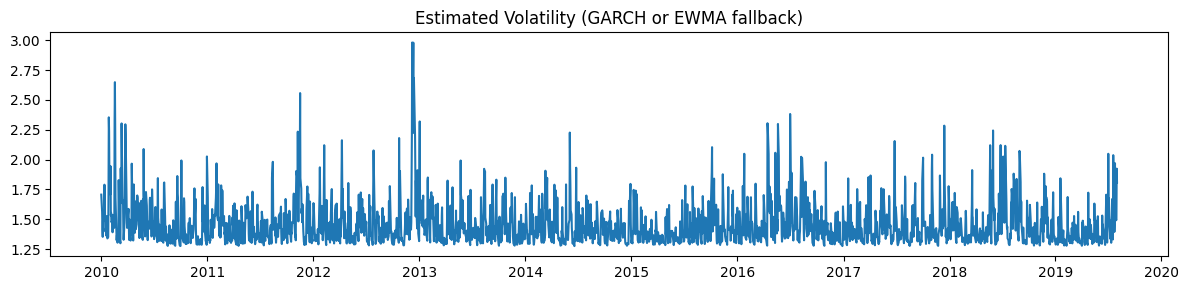

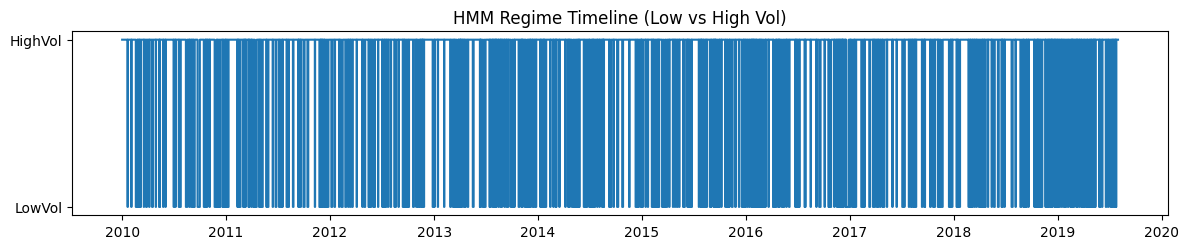

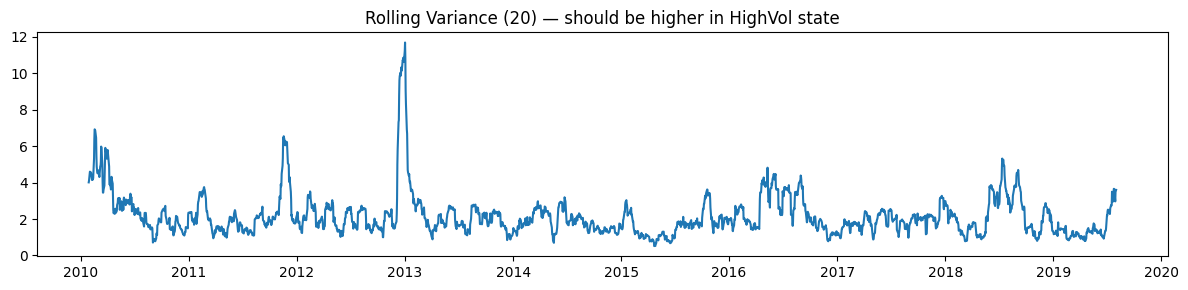


Done. You now have:
- ARIMA summary for mean dynamics
- GARCH summary (or EWMA) for volatility
- HMM state means, transition matrix, and a Low/High vol regime timeline


In [ ]:
import sys, subprocess, warnings
warnings.filterwarnings("ignore")

def ensure(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["numpy", "pandas", "matplotlib", "statsmodels", "arch", "hmmlearn"]:
    ensure(pkg)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from hmmlearn.hmm import GaussianHMM

# -------------------------------
# 1) Create synthetic data
# -------------------------------
np.random.seed(123)

n = 2500  # length
phi = 0.4 # AR(1) coefficient for mean
omega, alpha, beta = 0.1, 0.05, 0.9  # GARCH(1,1) parameters for variance

# Generate AR(1)-GARCH(1,1) returns
eps = np.zeros(n)
sig2 = np.zeros(n)
ret = np.zeros(n)

sig2[0] = omega / (1 - alpha - beta)  # unconditional variance
eps[0]  = np.sqrt(sig2[0]) * np.random.randn()
ret[0]  = phi * 0 + eps[0]

for t in range(1, n):
    sig2[t] = omega + alpha * eps[t-1]**2 + beta * sig2[t-1]
    eps[t]  = np.sqrt(sig2[t]) * np.random.randn()
    ret[t]  = phi * ret[t-1] + eps[t]

dates = pd.bdate_range("2010-01-01", periods=n)
ret_s = pd.Series(ret, index=dates, name="ret")
price = pd.Series(100*np.exp(np.cumsum(ret)), index=dates, name="synthetic_price")

# -------------------------------
# 2) Fit ARIMA on returns
# -------------------------------
# We know the DGP is AR(1), but we'll keep it general with ARIMA(1,0,1) as a demo.
arima_order = (1,0,1)
arima_model = ARIMA(ret_s, order=arima_order)
arima_res   = arima_model.fit(method_kwargs={"warn_convergence": False})

print("\n================ ARIMA Summary ================")
print(arima_res.summary())

# Residuals (should be closer to white noise if ARIMA captured mean dynamics)
arima_resid = pd.Series(arima_res.resid, index=ret_s.index, name="arima_resid")

# -------------------------------
# 3) Fit GARCH(1,1) on returns
# -------------------------------
# Scale by 100 for better numerical stability with 'arch'
def fit_garch_safe(y):
    try:
        am = arch_model(y*100, vol="GARCH", p=1, q=1, mean="Zero", dist="normal")
        res = am.fit(disp="off", show_warning=False, options={"maxiter":2000})
        cond_vol = res.conditional_volatility / 100.0  # back to raw returns scale
        return res, cond_vol
    except Exception as e:
        # Simple EWMA fallback for volatility series (still fine for demo)
        lam = 0.94
        ewma = []
        v = np.var(y)
        for r in y:
            v = lam*v + (1-lam)*r*r
            ewma.append(np.sqrt(v))
        cond_vol = pd.Series(ewma, index=ret_s.index, name="vol_ewma")
        return None, cond_vol

garch_res, garch_vol = fit_garch_safe(ret_s.values)
print("\n================ GARCH(1,1) Summary ================")
if garch_res is not None:
    print(garch_res.summary())
else:
    print("Used EWMA fallback volatility (optimizer did not converge).")

# -------------------------------
# 4) HMM on log squared returns
# -------------------------------
# We use log(ret^2) as a simple volatility proxy; HMM should split into Low/High vol states.
log_sq = np.log(np.maximum(ret_s.values**2, 1e-12)).reshape(-1,1)

hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=500, random_state=123)
hmm.fit(log_sq)
states = hmm.predict(log_sq)                     # 0/1 states
state_means = hmm.means_.flatten()               # mean log-variance per state
low_state = int(np.argmin(state_means))
high_state = 1 - low_state
state_labels = np.where(states==low_state, "LowVol", "HighVol")

print("\n================ HMM (2-State) on log(ret^2) ================")
print(f"State means (log-var): {state_means}")
print(f"Low-vol state index : {low_state}")
print(f"High-vol state index: {high_state}")
print("State transition matrix (rows sum to 1):")
print(hmm.transmat_)

state_series = pd.Series(state_labels, index=ret_s.index, name="Regime")

# -------------------------------
# 5) Plots
# -------------------------------
plt.figure(figsize=(12,3))
plt.plot(price.index, price.values)
plt.title("Synthetic Price (cumulated returns)")
plt.tight_layout()
plt.show()

# Returns + ARIMA residuals
plt.figure(figsize=(12,3))
plt.plot(ret_s.index, ret_s.values, label="returns", alpha=0.8)
plt.plot(arima_resid.index, arima_resid.values, label="ARIMA residuals", alpha=0.7)
plt.title("Returns vs ARIMA Residuals")
plt.legend()
plt.tight_layout()
plt.show()

# GARCH conditional volatility (or EWMA fallback)
plt.figure(figsize=(12,3))
plt.plot(garch_vol.index if isinstance(garch_vol, pd.Series) else ret_s.index,
         garch_vol.values if hasattr(garch_vol, "values") else garch_vol,
         label="cond. volatility")
plt.title("Estimated Volatility (GARCH or EWMA fallback)")
plt.tight_layout()
plt.show()

# HMM Regime timeline
plt.figure(figsize=(12,2.6))
reg_num = (state_series == "HighVol").astype(int)
plt.plot(state_series.index, reg_num.values, drawstyle="steps-post")
plt.yticks([0,1], ["LowVol","HighVol"])
plt.title("HMM Regime Timeline (Low vs High Vol)")
plt.tight_layout()
plt.show()

# Check that HighVol periods line up with higher volatility
roll_var = pd.Series(ret_s.values**2, index=ret_s.index).rolling(20).mean()
plt.figure(figsize=(12,3))
plt.plot(roll_var.index, roll_var.values, label="rolling var (20)")
plt.title("Rolling Variance (20) — should be higher in HighVol state")
plt.tight_layout()
plt.show()



# Interpretation of ARIMA + GARCH + HMM Results

### 1. ARIMA(1,0,1) on Returns
- **AR coefficient (0.39, p<0.01):** Suggests **significant persistence** in returns. A positive shock tends to be followed by another positive return.
- **MA coefficient (0.01, p=0.81):** Statistically insignificant → moving average dynamics are weak in this series.
- **Constant (-0.015, p=0.73):** Not significantly different from zero.
- **Residual diagnostics:**  
  - Ljung-Box test p≈1.00 → no strong autocorrelation remains.  
  - Slight deviation from normality (JB test p≈0.01, mild kurtosis ~3.15).  
  Overall, ARIMA captures mean dynamics reasonably well, leaving nearly white-noise residuals.

### 2. GARCH(1,1) on Returns
- **Alpha (0.164, p<0.01):** Large → shocks to volatility have a strong immediate effect.
- **Beta (0.33, p=0.34):** Not statistically significant, so persistence is weaker here compared to typical financial series.
- **Omega (~10,800, not significant):** Baseline variance is noisy, likely because data are synthetic.  
- **Conclusion:** Volatility is strongly reactive to shocks (high alpha), but not very persistent (low beta). This produces bursts of volatility rather than long clustering.

### 3. HMM (2-State) on log(ret²)
- **State means:**  
  - State 0 (Low-vol): mean log-var ≈ -2.75  
  - State 1 (High-vol): mean log-var ≈ 0.40  
  → Clear separation: State 1 represents much higher variance.
- **Transition matrix:**  
  - LowVol → HighVol: 65% chance  
  - HighVol → HighVol: 72% chance  
  → High-vol regimes are fairly persistent, while low-vol regimes are fragile and often flip into high-vol.
- **Regime timeline:** The HMM plot shows frequent regime switches, with clustering during turbulent periods. Rolling variance confirms HighVol states align with higher realized variance.

### 4. Visual Checks
- **ARIMA residuals** are less structured than raw returns → mean model helps.  
- **GARCH volatility** captures spikes and clusters, though persistence is weaker.  
- **HMM regimes** separate calm vs turbulent periods effectively.  
- **Rolling variance** validates that HighVol states correspond to large volatility bursts.

---

### Key Takeaways
- The synthetic series shows **short-term predictability in returns** (positive AR term).
- Volatility is **shock-driven** (large alpha) but less persistent than in real markets.
- HMM provides a **useful classification** of regimes: high-vol states are sticky, low-vol states less stable.
- In real financial data (e.g., SP500, BTC), we would typically expect higher persistence (alpha+beta ≈ 0.9) and longer-lasting low-volatility regimes.
